# CNN con atención

### Carga de dependencias y librerias

In [6]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import spacy
import gensim
from gensim.models import Word2Vec
from spellchecker import SpellChecker
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.nn.utils.rnn import pad_sequence

In [15]:
# Cargar el dataset
data = pd.read_csv("./jokes.csv")  # CAMBIAR LA RUTA DEL DATASET

### Paso 1: Preparación de Datos
Convertiremos los chistes en secuencias de números (tokens) y utilizaremos embeddings preentrenados.
Esta sección se encarga de preparar un conjunto de datos textuales para ser utilizado en un modelo de aprendizaje profundo. Primero, utiliza el modelo de procesamiento de lenguaje en español de spaCy para tokenizar los textos y un corrector ortográfico para limpiar y normalizar el texto, eliminando caracteres especiales, duplicados y corrigiendo errores.

Luego, transforma los textos en secuencias de índices utilizando un vocabulario construido a partir del corpus de entrenamiento. Los datos son divididos en conjuntos de entrenamiento y validación, y se crea un Dataset personalizado para manejar textos y etiquetas.
Finalmente, se implementa una función de colación para alinear las secuencias a la misma longitud mediante relleno y se generan DataLoaders que proporcionan los datos en lotes, listos para ser utilizados en el entrenamiento y evaluación del modelo.

In [18]:
# Cargar el modelo de spaCy para español
nlp = spacy.load("es_core_news_sm")

# Limpieza y corrección ortográfica
def clean_data_with_spellcheck(data):
    # Inicializar corrector ortográfico para español
    spell = SpellChecker(language='es')

    # Seleccionar columnas relevantes
    data = data[['jokeText', 'jokeHasHumor', 'jokeRate']]

    # Manejar valores nulos
    data = data.dropna(subset=['jokeText', 'jokeHasHumor', 'jokeRate'])

    # Convertir columnas a tipos adecuados
    data['jokeHasHumor'] = data['jokeHasHumor'].astype(int)  # Para clasificación binaria
    data['jokeRate'] = data['jokeRate'].astype(int)          # Para clasificación multiclase

    # Remover duplicados
    data = data.drop_duplicates(subset=['jokeText'])

    # Normalizar el texto
    data['jokeText'] = data['jokeText'].str.lower()                # Convertir a minúsculas
    data['jokeText'] = data['jokeText'].str.replace(r'\s+', ' ', regex=True)  # Remover espacios extras
    data['jokeText'] = data['jokeText'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)  # Remover caracteres especiales

    # Corregir errores ortográficos
    def correct_spelling(text):
        words = text.split()
        corrected_words = [
            spell.correction(word) if spell.correction(word) is not None else word for word in words
        ]
        return ' '.join(corrected_words)

    data['jokeText'] = data['jokeText'].apply(correct_spelling)

    return data

# Limpieza de los datos
data = clean_data_with_spellcheck(data)

# Dividir en conjuntos de entrenamiento y validación
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

# Tokenizador con spaCy
def spacy_tokenizer(text):
    return [token.text for token in nlp(text)]

# Crear vocabulario
def yield_tokens(data_iter):
    for text in data_iter['jokeText']:
        yield spacy_tokenizer(text)

vocab = build_vocab_from_iterator(yield_tokens(train_data), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

# Convertir texto a índices
def text_pipeline(text):
    return [vocab[token] for token in spacy_tokenizer(text)]

# Dataset personalizado
class JokeDataset(Dataset):
    def __init__(self, data, target_col):
        self.data = data
        self.target_col = target_col

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = text_pipeline(self.data.iloc[idx]['jokeText'])
        label = self.data.iloc[idx][self.target_col]
        return torch.tensor(text, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Definir la función de colación personalizada
def collate_fn(batch):
    texts, labels = zip(*batch)  # Desempacar las tuplas en textos y etiquetas
    texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)  # Rellenar secuencias
    labels = torch.tensor(labels)  # Convertir etiquetas en tensor
    return texts_padded, labels

# Crear DataLoaders con la función de colación personalizada
train_dataset = JokeDataset(train_data, 'jokeHasHumor')
val_dataset = JokeDataset(val_data, 'jokeHasHumor')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

Guardar los datos del preprocesamiento a un .csv como medida de punto de control futuro

In [19]:
# Exportar datos preprocesados a un archivo CSV
processed_data_path = "datos_preprocesados.csv"  # Especificar el nombre del archivo

# Guardar datos preprocesados
data.to_csv(processed_data_path, index=False)

print(f"Datos preprocesados exportados exitosamente a {processed_data_path}")

Datos preprocesados exportados exitosamente a datos_preprocesados.csv


Con la preparación de datos del dataset, ahora se procede a verificar la distribución grafica de los datos.

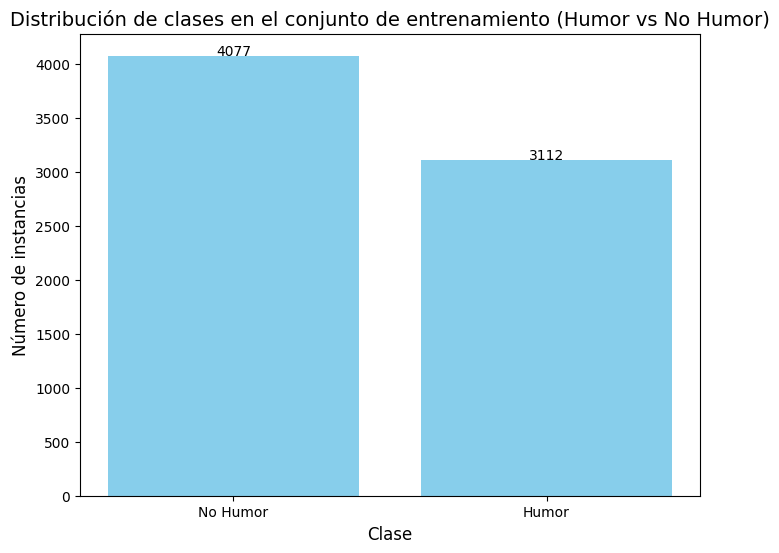

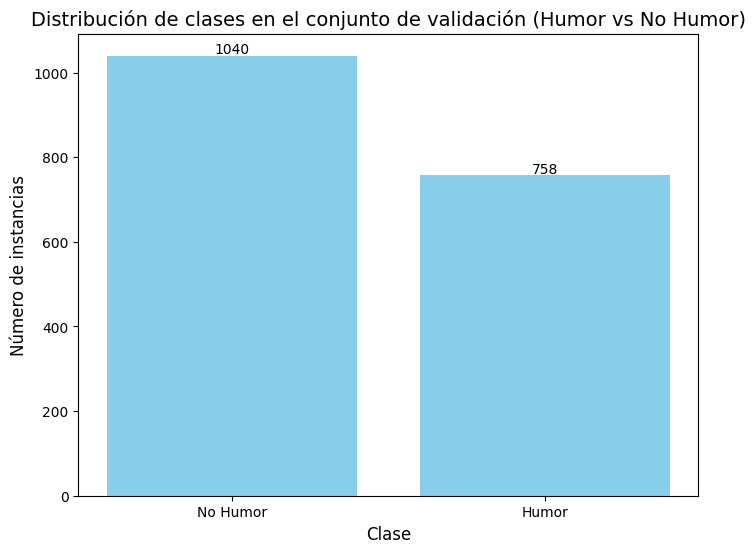

In [20]:
def plot_binary_distribution(data, title):
    # Contar las clases y asignar etiquetas
    class_counts = data['jokeHasHumor'].value_counts()
    labels = ["No Humor", "Humor"]  # Etiquetas personalizadas
    counts = [class_counts[0], class_counts[1]]

    # Crear la gráfica de barras
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, counts, color='skyblue')
    plt.xlabel("Clase", fontsize=12)
    plt.ylabel("Número de instancias", fontsize=12)
    plt.title(title, fontsize=14)

    # Etiquetas de los valores sobre las barras
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(bar.get_height()), ha='center', fontsize=10)

    plt.show()

# Graficar la distribución binaria en los conjuntos de entrenamiento y validación
plot_binary_distribution(train_data, "Distribución de clases en el conjunto de entrenamiento (Humor vs No Humor)")
plot_binary_distribution(val_data, "Distribución de clases en el conjunto de validación (Humor vs No Humor)")

Aqui se verifica la distribución de datos del dataset, en el conjunto de datos multiclase

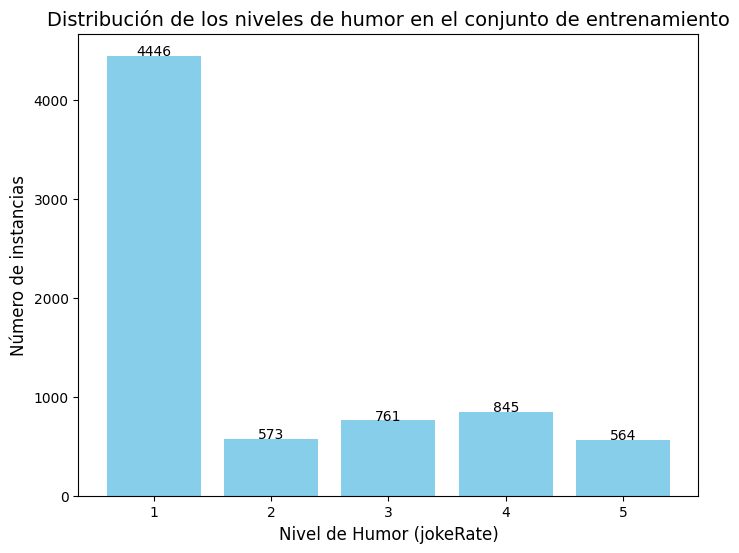

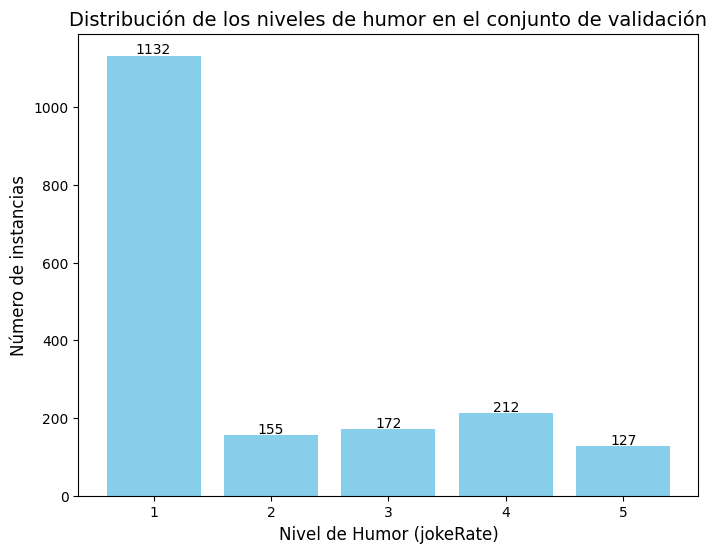

In [21]:
def plot_jokeRate_distribution(data, title):
    jokeRate_counts = data['jokeRate'].value_counts().sort_index()
    plt.figure(figsize=(8, 6))
    bars = plt.bar(jokeRate_counts.index, jokeRate_counts.values, color='skyblue')
    plt.xlabel("Nivel de Humor (jokeRate)", fontsize=12)
    plt.ylabel("Número de instancias", fontsize=12)
    plt.title(title, fontsize=14)
    plt.xticks(jokeRate_counts.index, fontsize=10)
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(bar.get_height()), ha='center', fontsize=10)
    plt.show()

# Graficar la distribución en los conjuntos de entrenamiento y validación
plot_jokeRate_distribution(train_data, "Distribución de los niveles de humor en el conjunto de entrenamiento")
plot_jokeRate_distribution(val_data, "Distribución de los niveles de humor en el conjunto de validación")

Se procede a correlacionar los datos procesados, con embeddings preentrenaos de Word2Vec. En esta sección, se cargan embeddings preentrenados en español desde el preprocesamiento de datos anterior, creando una matriz de embeddings para representar palabras del vocabulario único extraído de los datos de entrenamiento, y prepara DataLoaders para manejar el flujo de datos hacia un modelo de aprendizaje profundo.

Primero, se define una función para leer los embeddings desde el archivo y almacenarlos en un diccionario. Luego, se genera una matriz de embeddings donde cada palabra del vocabulario se mapea a su vector correspondiente, o a un vector aleatorio si no está presente en los embeddings preentrenados. Finalmente, se implementa un Dataset personalizado que convierte textos en índices basados en el vocabulario, y una función de colación que alinea las secuencias a una longitud común mediante relleno.
Los DataLoaders generados permiten iterar sobre los datos en lotes durante el entrenamiento y la evaluación del modelo.

In [22]:
# Ruta al archivo de embeddings
word2vec_model = Word2Vec.load("embeddings_300_5.model")

# Crear la matriz de embeddings
embedding_dim = word2vec_model.vector_size
vocab = set(train_data['jokeText'].str.split().explode().unique())  # Extraer vocabulario único de los textos
embedding_matrix = torch.zeros((len(vocab), embedding_dim))
word_to_index = {word: idx for idx, word in enumerate(vocab)}

for word, idx in word_to_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[idx] = torch.tensor(word2vec_model.wv[word])
    else:
        embedding_matrix[idx] = torch.randn(embedding_dim)

print("Matriz de embeddings creada correctamente.")

# 2. Preparar DataLoaders
def text_to_indices(text, word_to_index):
    return [word_to_index.get(word, 0) for word in text.split()]

class JokeDataset(Dataset):
    def __init__(self, data, target_col):
        self.texts = data['jokeText']
        self.labels = data[target_col]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_indices = text_to_indices(self.texts.iloc[idx], word_to_index)
        label = self.labels.iloc[idx]
        return torch.tensor(text_indices, dtype=torch.long), torch.tensor(label, dtype=torch.float)

# Crear DataLoaders
def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence([torch.tensor(text) for text in texts], batch_first=True, padding_value=0)
    labels = torch.tensor(labels)
    return texts_padded, labels

train_dataset = JokeDataset(train_data, 'jokeHasHumor')
val_dataset = JokeDataset(val_data, 'jokeHasHumor')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

print("DataLoaders preparados correctamente con los embeddings preentrenados.")

Matriz de embeddings creada correctamente.
DataLoaders preparados correctamente con los embeddings preentrenados.


### Paso 2: Definición del Modelo
Implementaremos una arquitectura que combine CNN con un mecanismo de atención. Para ello, este código define un modelo de red neuronal basado en CNN con atención y dropout para la clasificación binaria, entrenándolo con diferentes tasas de aprendizaje para ajustar los embeddings preentrenados y las demás capas del modelo.
El modelo incluye una capa de embeddings inicializada con vectores preentrenados, una capa CNN para capturar dependencias secuenciales, un mecanismo de atención para enfocar partes relevantes de la secuencia, y una capa fully-connected para generar la salida final.

Durante el entrenamiento, las tasas de aprendizaje diferenciadas permiten un ajuste gradual (fine-tuning) de los embeddings mientras las demás capas se entrenan con mayor libertad.
Además, se utiliza dropout para prevenir sobreajuste, y se evalúan métricas como pérdida y precisión en los conjuntos de entrenamiento y validación. El entrenamiento se realiza en múltiples épocas utilizando lotes de datos, con optimización a través del algoritmo Adam

In [23]:
class Config:
    hidden_dim = 512
    dropout_prob = 0.3
    learning_rate_embeddings = 1e-5
    learning_rate_rest = 5e-4
    weight_decay = 1e-4
    batch_size = 32
    num_classes = len(data['jokeRate'].unique())

vocab_size = len(vocab)
embedding_dim = embedding_matrix.shape[1]
num_filters = 128
filter_sizes = [3, 4, 5]
attention_dim = 64
dropout_prob = 0.3
num_classes = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SelfAttention(nn.Module):
    def __init__(self, input_dim, attention_dim):
        super(SelfAttention, self).__init__()
        self.attention_weights = nn.Linear(input_dim, attention_dim)
        self.context_vector = nn.Linear(attention_dim, 1)

    def forward(self, x):
        attention_scores = self.attention_weights(x)
        attention_scores = torch.tanh(attention_scores)
        attention_scores = self.context_vector(attention_scores)
        attention_weights = torch.softmax(attention_scores, dim=1)
        context_vector = torch.sum(attention_weights * x, dim=1)
        return context_vector


class CNNSelfAttentionModelMulticlass(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes, attention_dim, dropout_prob, num_classes, embedding_matrix=None):
        super(CNNSelfAttentionModelMulticlass, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        if embedding_matrix is not None:
            if isinstance(embedding_matrix, torch.Tensor):
                embedding_matrix_tensor = embedding_matrix.float()
            else:
                embedding_matrix_tensor = torch.from_numpy(embedding_matrix).float()
            self.embedding.weight.data.copy_(embedding_matrix_tensor)

        self.conv_layers = nn.ModuleList([
            nn.Conv2d(in_channels=1, out_channels=num_filters, kernel_size=(fs, embedding_dim))
            for fs in filter_sizes
        ])
        self.attention = SelfAttention(num_filters * len(filter_sizes), attention_dim)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = self.embedding(x)
        x = x.unsqueeze(1)
        conv_out = [torch.relu(conv(x)).squeeze(3) for conv in self.conv_layers]
        conv_out = [torch.max(out, dim=2)[0] for out in conv_out]
        conv_out = torch.cat(conv_out, dim=1)
        attention_out = self.attention(conv_out.unsqueeze(1))
        attention_out = self.dropout(attention_out)
        output = self.fc(attention_out)
        return output


# Definir el dispositivo de cómputo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instanciar el modelo con Configuración centralizada
combined_embedding_dim = embedding_matrix.shape[1]

model = CNNSelfAttentionModelMulticlass(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_filters=num_filters,
    filter_sizes=filter_sizes,
    attention_dim=attention_dim,
    dropout_prob=dropout_prob,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix
).to(device)

# Optimizador ajustado
optimizer = optim.Adam([
    {'params': model.embedding.parameters(), 'lr': Config.learning_rate_embeddings},  # Embeddings
    {'params': model.conv_layers.parameters()},  # Capas convolucionales
    {'params': model.attention.parameters()},  # Atención
    {'params': model.fc.parameters()},  # Capa fully connected
], lr=Config.learning_rate_rest, weight_decay=1e-5)

# DataLoaders ajustados
train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=Config.batch_size, shuffle=False, collate_fn=collate_fn)

# Scheduler para ajuste dinámico de la tasa de aprendizaje
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=5, verbose=True
)

# Mostrar los hiperparámetros utilizados
print(f"Hyperparameters: hidden_dim={Config.hidden_dim}, dropout_prob={Config.dropout_prob}, "
      f"learning_rate_embeddings={Config.learning_rate_embeddings}, learning_rate_rest={Config.learning_rate_rest}, "
      f"weight_decay={Config.weight_decay}, batch_size={Config.batch_size}")


Hyperparameters: hidden_dim=512, dropout_prob=0.3, learning_rate_embeddings=1e-05, learning_rate_rest=0.0005, weight_decay=0.0001, batch_size=32


### Paso 3: Entrenamiento
Entrenaremos el modelo para la tarea multiclase. Esta sección implementa un pipeline de entrenamiento para un modelo de clasificación multiclase con Early Stopping. Primero, inicializa el modelo CNNSelfAttentionModelMulticlass con embeddings preentrenados, una CNN con atención y Dropout, configurando también un optimizador Adam con diferentes tasas de aprendizaje para las capas del modelo.

Durante el entrenamiento, el modelo ajusta sus parámetros minimizando la pérdida de entropía cruzada binaria. Se evalúa en cada época usando un conjunto de validación para calcular la pérdida y precisión. La lógica de Early Stopping detiene el entrenamiento si no hay mejoras en la pérdida de validación durante un número consecutivo de épocas definido por patience. Si se activa, se restaura automáticamente el estado del modelo con el mejor desempeño en validación. Finalmente, se ejecuta el entrenamiento completo utilizando estos elementos.

In [25]:

# Función para calcular métricas de evaluación
def calculate_metrics_multiclass(predictions, labels):
    preds = torch.argmax(predictions, dim=1).cpu().numpy()
    labels = labels.cpu().numpy()
    precision = precision_score(labels, preds, average='weighted', zero_division=0)
    recall = recall_score(labels, preds, average='weighted', zero_division=0)
    f1 = f1_score(labels, preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(labels, preds)
    return precision, recall, f1, accuracy

# Función de entrenamiento
def train_model_with_self_attention_and_scheduler(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=50, patience=8
):
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None  # Guardar el mejor modelo

    # Inicializar historial
    history = {
        'train_loss': [], 'val_loss': [],
        'train_precision': [], 'val_precision': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_accuracy': [], 'val_accuracy': []
    }

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        all_train_predictions = []  # Inicializar como lista
        all_train_labels = []       # Inicializar como lista

        print(f"\nEpoch {epoch + 1}/{epochs}")

        for batch in train_loader:
            texts, labels = batch
            texts, labels = texts.to(device), labels.to(device).long()  # Asegurar tipo LongTensor

            optimizer.zero_grad()
            predictions = model(texts)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

            # Almacenar resultados
            all_train_predictions.append(predictions.detach())  # Detach para evitar acumulación en el gráfico computacional
            all_train_labels.append(labels.detach())

        # Métricas de entrenamiento
        all_train_predictions = torch.cat(all_train_predictions)  # Concatenar al final
        all_train_labels = torch.cat(all_train_labels)
        train_precision, train_recall, train_f1, train_accuracy = calculate_metrics_multiclass(all_train_predictions, all_train_labels)

        # Actualizar historial de entrenamiento
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['train_precision'].append(train_precision)
        history['train_recall'].append(train_recall)
        history['train_f1'].append(train_f1)
        history['train_accuracy'].append(train_accuracy)

        # Imprimir métricas de entrenamiento
        print(f"  Train Loss: {history['train_loss'][-1]:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}, Accuracy: {train_accuracy:.4f}")

        # Validación
        model.eval()
        val_loss = 0
        all_val_predictions = []  # Inicializar como lista
        all_val_labels = []       # Inicializar como lista

        with torch.no_grad():
            for batch in val_loader:
                texts, labels = batch
                texts, labels = texts.to(device), labels.to(device).long()  # Asegurar tipo LongTensor
                predictions = model(texts)
                val_loss += criterion(predictions, labels).item()
                all_val_predictions.append(predictions)
                all_val_labels.append(labels)

        # Métricas de validación
        all_val_predictions = torch.cat(all_val_predictions)
        all_val_labels = torch.cat(all_val_labels)
        val_precision, val_recall, val_f1, val_accuracy = calculate_metrics_multiclass(all_val_predictions, all_val_labels)

        # Actualizar historial de validación
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['val_f1'].append(val_f1)
        history['val_accuracy'].append(val_accuracy)

        # Imprimir métricas de validación
        print(f"  Val Loss: {history['val_loss'][-1]:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}, Accuracy: {val_accuracy:.4f}")

        # Scheduler para ajuste dinámico de la tasa de aprendizaje
        scheduler.step(val_loss)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
            print(f"  Validation Loss improved to {best_val_loss:.4f}. Saving model...")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

    # Restaurar el mejor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Best model restored.")

    return history


# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Entrenar el modelo
history = train_model_with_self_attention_and_scheduler(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=50, patience=8
)


Epoch 1/50


<ipython-input-22-6d16c472c89c>:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts_padded = pad_sequence([torch.tensor(text) for text in texts], batch_first=True, padding_value=0)


  Train Loss: 0.6371, Precision: 0.6341, Recall: 0.6386, F1: 0.6326, Accuracy: 0.6386


<ipython-input-22-6d16c472c89c>:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts_padded = pad_sequence([torch.tensor(text) for text in texts], batch_first=True, padding_value=0)


  Val Loss: 0.7016, Precision: 0.5449, Recall: 0.5451, F1: 0.5450, Accuracy: 0.5451
  Validation Loss improved to 39.9939. Saving model...

Epoch 2/50


...

  Val Loss: 0.9366, Precision: 0.5423, Recall: 0.5601, F1: 0.5406, Accuracy: 0.5601
  No improvement. Patience counter: 7/8

Epoch 9/50


<ipython-input-22-6d16c472c89c>:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts_padded = pad_sequence([torch.tensor(text) for text in texts], batch_first=True, padding_value=0)


  Train Loss: 0.3103, Precision: 0.8714, Recall: 0.8716, F1: 0.8715, Accuracy: 0.8716


<ipython-input-22-6d16c472c89c>:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts_padded = pad_sequence([torch.tensor(text) for text in texts], batch_first=True, padding_value=0)


  Val Loss: 0.9542, Precision: 0.5427, Recall: 0.5573, F1: 0.5433, Accuracy: 0.5573
  No improvement. Patience counter: 8/8
Early stopping triggered!
Best model restored.


In [27]:
# Evaluar diferentes thresholds (corregido para multiclase)
def evaluate_thresholds_multiclass(model, data_loader):
    model.eval()
    results = {"precision": [], "recall": [], "f1": [], "accuracy": []}
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in data_loader:
            texts, labels = texts.to(device), labels.to(device)
            predictions = model(texts)
            all_predictions.append(predictions)  # Sin umbrales
            all_labels.append(labels)

    # Concatenar todas las predicciones y etiquetas
    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)

    # Convertir logits/probabilidades a etiquetas de clase
    predicted_labels = torch.argmax(all_predictions, dim=1).cpu().numpy()
    true_labels = all_labels.cpu().numpy()

    # Calcular métricas
    precision = precision_score(true_labels, predicted_labels, average="weighted", zero_division=0)
    recall = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
    f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)
    accuracy = accuracy_score(true_labels, predicted_labels)

    results["precision"] = precision
    results["recall"] = recall
    results["f1"] = f1
    results["accuracy"] = accuracy

    return results

# Evaluar modelo en el conjunto de validación
results = evaluate_thresholds_multiclass(model, val_loader)
print(f"Precision: {results['precision']:.4f}, Recall: {results['recall']:.4f}, F1: {results['f1']:.4f}, Accuracy : {results['accuracy']:.4f}")

<ipython-input-22-6d16c472c89c>:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts_padded = pad_sequence([torch.tensor(text) for text in texts], batch_first=True, padding_value=0)


Precision: 0.5427, Recall: 0.5573, F1: 0.5433, Accuracy : 0.5573


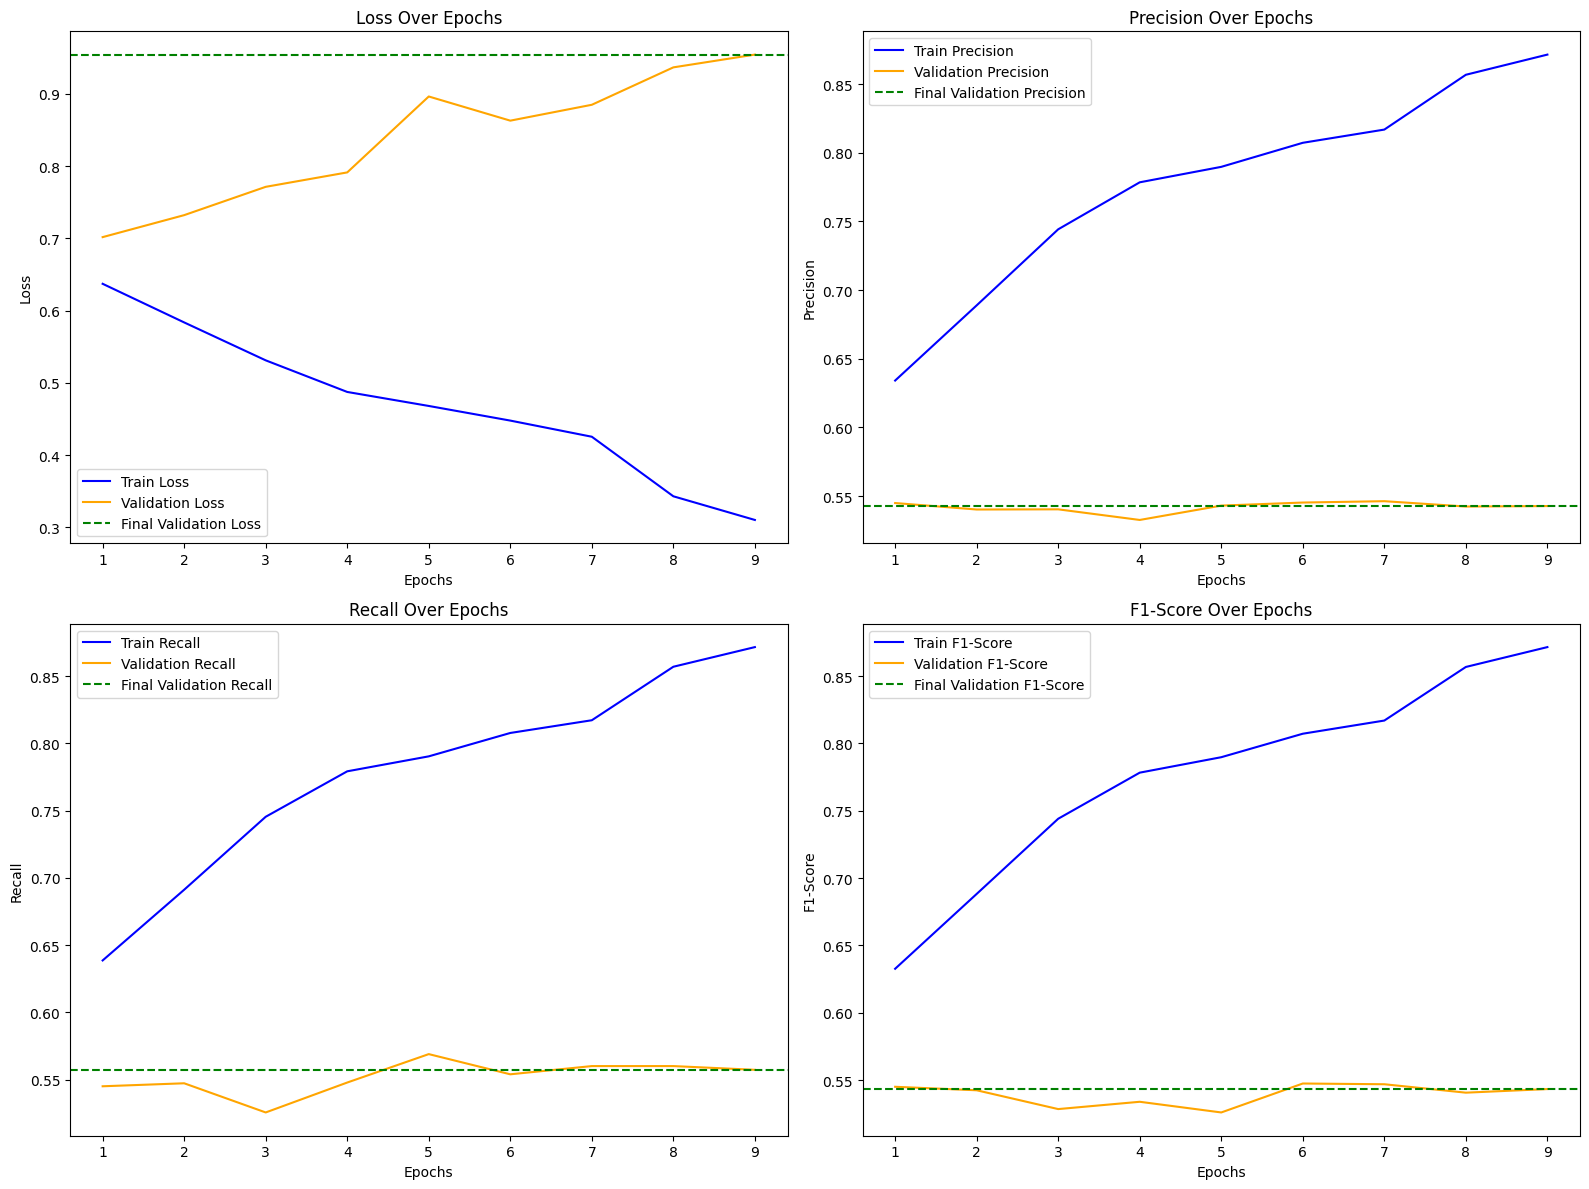

In [28]:
# Función actualizada para graficar métricas con evaluación final
def plot_metrics_with_evaluation(history):
    epochs = len(history['train_loss'])

    plt.figure(figsize=(16, 12))

    # Pérdida
    plt.subplot(2, 2, 1)
    plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss', color='blue')
    plt.plot(range(1, epochs + 1), history['val_loss'], label='Validation Loss', color='orange')
    plt.axhline(history['val_loss'][-1], color='green', linestyle='--', label='Final Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Over Epochs')
    plt.legend()

    # Precisión
    plt.subplot(2, 2, 2)
    plt.plot(range(1, epochs + 1), history['train_precision'], label='Train Precision', color='blue')
    plt.plot(range(1, epochs + 1), history['val_precision'], label='Validation Precision', color='orange')
    plt.axhline(history['val_precision'][-1], color='green', linestyle='--', label='Final Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.title('Precision Over Epochs')
    plt.legend()

    # Recall
    plt.subplot(2, 2, 3)
    plt.plot(range(1, epochs + 1), history['train_recall'], label='Train Recall', color='blue')
    plt.plot(range(1, epochs + 1), history['val_recall'], label='Validation Recall', color='orange')
    plt.axhline(history['val_recall'][-1], color='green', linestyle='--', label='Final Validation Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.title('Recall Over Epochs')
    plt.legend()

    # F1-Score
    plt.subplot(2, 2, 4)
    plt.plot(range(1, epochs + 1), history['train_f1'], label='Train F1-Score', color='blue')
    plt.plot(range(1, epochs + 1), history['val_f1'], label='Validation F1-Score', color='orange')
    plt.axhline(history['val_f1'][-1], color='green', linestyle='--', label='Final Validation F1-Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1-Score')
    plt.title('F1-Score Over Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Llamar a la función para graficar métricas
plot_metrics_with_evaluation(history)

<ipython-input-22-6d16c472c89c>:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts_padded = pad_sequence([torch.tensor(text) for text in texts], batch_first=True, padding_value=0)


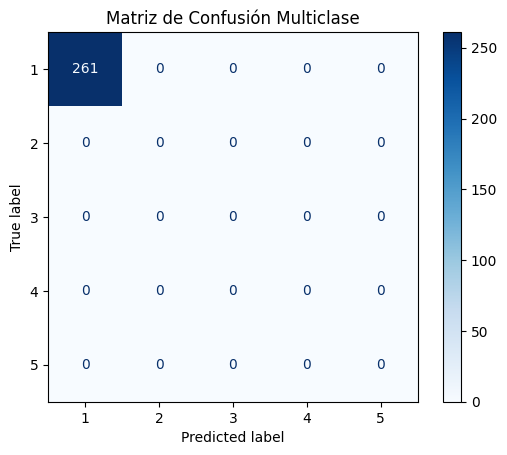

In [29]:
# Generar matriz de confusión multiclase corregida
def plot_confusion_matrix_multiclass(model, data_loader, class_labels):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in data_loader:
            texts, labels = texts.to(device), labels.to(device)
            predictions = model(texts)
            all_predictions.append(torch.argmax(predictions, dim=1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # Concatenar todas las predicciones y etiquetas
    all_predictions = np.concatenate(all_predictions)
    all_labels = np.concatenate(all_labels)

    # Generar matriz de confusión
    cm = confusion_matrix(all_labels, all_predictions, labels=class_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión Multiclase")
    plt.show()

# Obtener etiquetas de clases de los datos de validación
class_labels = sorted(train_data['jokeRate'].unique())  # Clases presentes en los datos
plot_confusion_matrix_multiclass(model, val_loader, class_labels)

### Paso 4: Evaluación
Evaluaremos el modelo con métricas como precisión, recall, F1, y exactitud. Esta sección, define un flujo completo de entrenamiento y validación de un modelo, incluyendo el cálculo y registro de métricas clave como precisión, recall, F1-score y exactitud. La función calculate_metrics convierte las predicciones del modelo en valores binarios mediante una función sigmoide y un umbral de 0.5, y calcula las métricas al comparar estas predicciones con las etiquetas reales.
Durante el entrenamiento, la función train_model_with_metrics_and_plot acumula predicciones y etiquetas en cada época para calcular las métricas de entrenamiento, mientras optimiza los pesos del modelo mediante gradiente descendente.

Luego, evalúa el modelo en el conjunto de validación, acumulando predicciones y etiquetas para calcular las mismas métricas en validación.
Los resultados de pérdida y métricas se registran en un historial (history) para cada época, permitiendo comparaciones entre entrenamiento y validación, y proporcionando un resumen detallado de la evolución del modelo.

### Análisis cuantitativo detallado
Esta sección, realiza dos tareas principales: graficar las métricas de entrenamiento y validación, y mostrar una matriz de confusión normalizada basada en los resultados de validación del modelo.

La función plot_metrics genera gráficos comparativos entre entrenamiento y validación para pérdida, precisión, recall y F1-score, destacando cómo evolucionan estas métricas a lo largo de las épocas de entrenamiento. Verifica que los datos correspondientes estén disponibles en el historial antes de graficar. La función plot_confusion_matrix, por otro lado, evalúa el modelo en el conjunto de validación, recopila las predicciones y etiquetas verdaderas, calcula una matriz de confusión normalizada y la presenta visualmente con etiquetas 'No Humor' y 'Humor', ayudando a entender el desempeño del modelo en términos de clasificación correcta e incorrecta.

Finalmente, se entrena el modelo con la función train_model_with_metrics_and_plot y se grafican tanto las métricas como la matriz de confusión para una evaluación exhaustiva del desempeño del modelo.